In [1]:
%pip install pybamm -q    # install PyBaMM if it is not installed
import pybamm
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.chdir(pybamm.__path__[0]+'/..')

Note: you may need to restart the kernel to use updated packages.


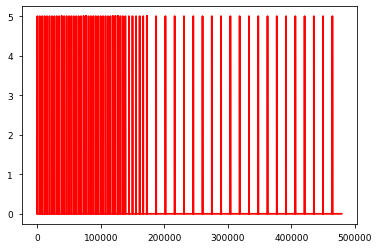

In [2]:
model = pybamm.lithium_ion.DFN()
chemistry = pybamm.parameter_sets.Chen2020_plating
parameter_values = pybamm.ParameterValues(chemistry=chemistry)
parameter_values.update({"Ambient temperature [K]": 288.15})

# import GITT current from file
GITT_current = pd.read_csv(
    "/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_15deg_Niall.csv", comment="#", header=None
).to_numpy()

# create interpolant
timescale = parameter_values.evaluate(model.timescale)
current_interpolant = pybamm.Interpolant(GITT_current[:, 0], -GITT_current[:, 1]/1000, timescale * pybamm.t)

I = current_interpolant.evaluate(t=GITT_current[:,0]/timescale)
fig, ax = plt.subplots()
ax.plot(GITT_current[:,0],I)
plt.show()

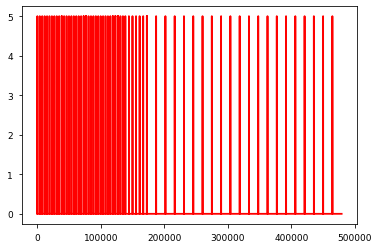

In [3]:
fig, ax = plt.subplots()
ax.plot(GITT_current[:,0],-GITT_current[:,1]/1000)
plt.show()

In [ ]:
# set current function
parameter_values["Current function [A]"] = current_interpolant

sim = pybamm.Simulation(model, parameter_values=parameter_values, solver=pybamm.CasadiSolver(mode="fast"))
solution1 = sim.solve()
timer = pybamm.Timer()
print(solution1.solve_time)

In [ ]:
solution1.save('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pkl')

In [ ]:
solution1 = pybamm.load('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pkl')

In [ ]:
fig, ax = plt.subplots()
t = solution1["Time [h]"].entries
V = solution1["Terminal voltage [V]"].entries
ax.plot(t,V)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Terminal voltage [V]")
plt.savefig('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pdf')
plt.show()

In [ ]:
fig, ax = plt.subplots()
t = solution1["Time [s]"].entries
V = solution1["Current [A]"].entries
ax.plot(t,V)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Current [A]")
#plt.savefig('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pdf')
plt.show()